# Sentiment Prototype Learning — Steps 3 to 7 (End-to-End)

### Where we are in the pipeline
```
preprocess.ipynb
       |
       |----------------------------------+
       v                                  v
BERT_embedding.ipynb            ViT_embedding.ipynb
       |                                  |
       v                                  v
text_embeddings.jsonl       image_embeddings.jsonl
       |                                  |
       +-----------------+----------------+
                         v
                   merge.ipynb
                   (also writes split_train / split_val / split_test)
                         |
                         v
          prototype_learning.ipynb   <-- NOTEBOOK WORKS HERE
                         |
                         v
          interactions_prototype.jsonl
```

### Steps 3 → 7

**Step 3 — Sentiment Prototype Space**
Learn a matrix `S ∈ R^(K×768)` of prototype vectors.
K starts at 5 and **grows dynamically** when the model needs more sentiment
directions, and **prunes** prototypes that are never attended to.

**Step 4 — Prototype Attention**
For each interaction softmax attention is computed over prototypes for both
the image embedding `v_i` and the text embedding `t_ui`, then form
sentiment-aware representations `z_v` and `z_t` as weighted sums of prototypes.

**Step 5 — Cross-Modal Consistency Loss**
Penalising disagreement between `z_v` and `z_t` using `||z_v - z_t||²`.
Combined with the MSE rating loss this tries to make the image and text to agree
on the same sentiment reading.

**Step 6 — User-Guided Gating**
A learnable user embedding `u ∈ R^du` (randomly initialised, trained purely
by backpropagation through the MSE loss) captures each user's persistent
modality preference. A gating network combines `[z_v ; z_t ; u]` to produce
a per-dimension gate that blends the two modalities:
`g = σ(Wg [z_v ; z_t ; u])`
`Z_ui = g ⊙ z_v + (1-g) ⊙ z_t`

**Step 7 — Rating Prediction**
`ŷ_ui = Wr^T Z_ui + br`

### Training / Validation / Test
Splits are loaded from `split_train.jsonl`, `split_val.jsonl`, `split_test.jsonl`
produced by the final cell of `merge.ipynb`. The best model (by validation MSE)
is checkpointed and restored before test evaluation.

### Output
`interactions_prototype.jsonl` — records augmented with `z_v`, `z_t`, and the
learned gate `g`, ready for downstream inspection or re-use.

## Cell 1 - Mount Drive

In [112]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Cell 2 — Install dependencies

In [113]:
!pip install torch numpy matplotlib scikit-learn tqdm

---
## Cell 3 — Imports

In [114]:
import json
import math
import random
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from collections import defaultdict
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

print("Imports OK")

Imports OK


---
## Cell 4 — Configuration

All hyperparameters present along with explanations.

In [115]:
# ── I/O ───────────────────────────────────────────────────────────────────────
# Split files produced by the final cell of merge.ipynb

#previously from local runtime memory
# TRAIN_PATH  = "split_train.jsonl"
# VAL_PATH    = "split_val.jsonl"
# TEST_PATH   = "split_test.jsonl"
# OUTPUT_PATH = "interactions_prototype.jsonl"

#From Google Drive
DRIVE_BASE  = "/content/drive/MyDrive/multimodal_rec"

TRAIN_PATH  = f"{DRIVE_BASE}/split_train.jsonl"
VAL_PATH    = f"{DRIVE_BASE}/split_val.jsonl"
TEST_PATH   = f"{DRIVE_BASE}/split_test.jsonl"
OUTPUT_PATH = f"{DRIVE_BASE}/interactions_prototype.jsonl"


# ── Embedding ─────────────────────────────────────────────────────────────────
EMB_DIM = 768          # dimension of text_embedding and image_embedding

# ── Prototype hyperparameters ─────────────────────────────────────────────────
K_INIT = 5             # starting number of prototypes
K_MAX  = 30            # hard ceiling — prototypes will never exceed this

# Grow trigger: if avg attention entropy > H_MAX_RATIO * log(K), add new prototype
# 0.87 means "if attention is spread across 87% of max possible entropy, more prototypes needed"
H_MAX_RATIO = 0.87

# Prune trigger:
#  if a prototype's avg attention wt falls below PRUNE_THRESHOLD across the whole epoch, it's removed
# 1/K * 0.3 means "less than 30% of the fair share of attention"
PRUNE_RATIO = 0.3  #increase to 0.4 or 0.5 if after scaling pruning does not occur

# Diversity loss weight: penalizes prototype collapse by enforcing near-orthogonality
# Starts at 0.1. If prototypes still collapse (clustering in PCA), increase to 0.2 - 0.5
# If training becomes unstable (loss oscillates), reduce to 0.05
LAMBDA_DIVERSITY = 0.1

# ── User embedding ────────────────────────────────────────────────────────────
# Dimension of each user's learnable embedding vector (Step 6).
# Intentionally much smaller than EMB_DIM
# User embeddings need to carry a low-dimensional modality-preference signal, not semantic content
USER_EMB_DIM = 64 #128 at full scale

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS        = 80
BATCH_SIZE    = 32
LEARNING_RATE = 1e-3

# Lambda controls how strongly the consistency loss is weighted relative to rating MSE loss
# Start at 0.3
# Increase if z_v and z_t diverge a lot
LAMBDA_CONSISTENCY = 0.03

# Early stopping patience when value of MSE stops improving
EARLY_STOP_PATIENCE = 12  #Needs to increase to 15 at full scale

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Train split      : {TRAIN_PATH}")
print(f"Val split        : {VAL_PATH}")
print(f"Test split       : {TEST_PATH}")
print(f"Output           : {OUTPUT_PATH}")
print(f"EMB_DIM          : {EMB_DIM}")
print(f"USER_EMB_DIM     : {USER_EMB_DIM}")
print(f"K_INIT / K_MAX   : {K_INIT} / {K_MAX}")
print(f"Epochs           : {EPOCHS}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Learning rate    : {LEARNING_RATE}")
print(f"Lambda consist.  : {LAMBDA_CONSISTENCY}")
print(f"Device           : {DEVICE}")

Train split      : /content/drive/MyDrive/multimodal_rec/split_train.jsonl
Val split        : /content/drive/MyDrive/multimodal_rec/split_val.jsonl
Test split       : /content/drive/MyDrive/multimodal_rec/split_test.jsonl
Output           : /content/drive/MyDrive/multimodal_rec/interactions_prototype.jsonl
EMB_DIM          : 768
USER_EMB_DIM     : 64
K_INIT / K_MAX   : 5 / 30
Epochs           : 80
Batch size       : 32
Learning rate    : 0.001
Lambda consist.  : 0.03
Device           : cpu


---
## Cell 5 — Dataset

Loads each split file and returns tensors per interaction.
Ratings are normalised from [1, 5] to [0, 1] so the MSE loss has a stable scale.

Three dataset objects are created — `dataset_train`, `dataset_val`, `dataset_test` —
and three corresponding DataLoaders. The training loader shuffles; val and test
loaders do not (order doesn't matter for evaluation).

In [116]:
class MultimodalDataset(Dataset):
    """
    Each item is one (user, asin) interaction from a split JSONL file.
    Returns:
        text_emb    : torch.FloatTensor  shape (EMB_DIM,)  — L2-normalised BERT embedding
        image_emb   : torch.FloatTensor  shape (EMB_DIM,)  — L2-normalised CLIP embedding
        rating      : torch.FloatTensor  scalar in [0, 1]  — normalised from [1, 5]
        user_id     : str
        asin        : str
    """

    def __init__(self, path: str):
        self.records = []
        skipped = 0
        with open(path) as f:
            for i, line in enumerate(f):
                line = line.strip()
                if not line:
                    continue
                rec = json.loads(line)

                t = rec.get("text_embedding")
                v = rec.get("image_embedding")
                r = rec.get("rating")

                if t is None or v is None or r is None:
                    skipped += 1
                    continue
                if len(t) != EMB_DIM or len(v) != EMB_DIM:
                    skipped += 1
                    continue

                self.records.append({
                    "text_emb"   : torch.tensor(t, dtype=torch.float32),
                    "image_emb"  : torch.tensor(v, dtype=torch.float32),
                    # Normalise rating to [0,1]: (r-1)/4
                    "rating"     : torch.tensor((float(r) - 1.0) / 4.0, dtype=torch.float32),
                    "user_id"    : rec["user_id"],
                    "asin"       : rec["asin"],
                    "parent_asin": rec.get("parent_asin"),
                    "timestamp"  : rec.get("timestamp"),
                    "raw_rating" : float(r),
                })

        print(f"  Loaded  : {len(self.records):,} interactions  ({path})")
        if skipped:
            print(f"  Skipped : {skipped} records (missing fields or wrong dim)")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        return self.records[idx]


def collate_fn(batch):
    """Custom collate to keep string fields separate from tensors."""
    return {
        "text_emb"   : torch.stack([b["text_emb"]   for b in batch]),
        "image_emb"  : torch.stack([b["image_emb"]  for b in batch]),
        "rating"     : torch.stack([b["rating"]      for b in batch]),
        "user_id"    : [b["user_id"]     for b in batch],
        "asin"       : [b["asin"]        for b in batch],
        "parent_asin": [b["parent_asin"] for b in batch],
        "timestamp"  : [b["timestamp"]   for b in batch],
        "raw_rating" : [b["raw_rating"]  for b in batch],
    }


print("Loading splits...")
dataset_train = MultimodalDataset(TRAIN_PATH)
dataset_val   = MultimodalDataset(VAL_PATH)
dataset_test  = MultimodalDataset(TEST_PATH)

loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
loader_val   = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
loader_test  = DataLoader(dataset_test,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\nBatches — train: {len(loader_train)} | val: {len(loader_val)} | test: {len(loader_test)}")

Loading splits...
  Loaded  : 2,875 interactions  (/content/drive/MyDrive/multimodal_rec/split_train.jsonl)
  Loaded  : 1,524 interactions  (/content/drive/MyDrive/multimodal_rec/split_val.jsonl)
  Loaded  : 2,619 interactions  (/content/drive/MyDrive/multimodal_rec/split_test.jsonl)

Batches — train: 90 | val: 48 | test: 82


---
## Cell 6 — User Index

Assigns a stable integer index to every user seen in the **training set**.
Users who appear only in val or test (OOV users) fall back to index 0 at inference time. This is safe: Out Of Vocabulary users don't update the embedding table during training so they don't corrupt learned embeddings; and at inference they simply receive the embedding of the "average" user at slot 0.

In [117]:
# Build user index from training data only leaving 0 for OOV
all_train_uids = sorted({r["user_id"] for r in dataset_train.records})
user_to_idx    = {uid: i+1 for i, uid in enumerate(all_train_uids)}
NUM_USERS      = len(all_train_uids) + 1 #for the OOV slot at index 0

print(f"Unique users in training set : {NUM_USERS}")
print(f"User embedding table shape   : ({NUM_USERS}, {USER_EMB_DIM})")
print(f"Val users                    : {len({r['user_id'] for r in dataset_val.records})}")
print(f"Test users                   : {len({r['user_id'] for r in dataset_test.records})}")

# OOV check: how many val/test users are unseen in training
val_uids  = {r["user_id"] for r in dataset_val.records}
test_uids = {r["user_id"] for r in dataset_test.records}
train_uid_set = set(all_train_uids)

oov_val  = len(val_uids  - train_uid_set)
oov_test = len(test_uids - train_uid_set)
print(f"OOV users in val             : {oov_val}  (will use fallback index 0)")
print(f"OOV users in test            : {oov_test}  (will use fallback index 0)")


def get_user_indices(user_ids: list, mapping: dict, device) -> torch.Tensor:
    """
    Convert a list of user_id strings to a LongTensor of embedding-table indices.
    Users not in mapping (OOV) fall back to index 0.
    """
    return torch.tensor(
        [mapping.get(uid, 0) for uid in user_ids],
        dtype=torch.long,
        device=device,
    )

print("\nget_user_indices() defined.")

Unique users in training set : 835
User embedding table shape   : (835, 64)
Val users                    : 1435
Test users                   : 2530
OOV users in val             : 601  (will use fallback index 0)
OOV users in test            : 1696  (will use fallback index 0)

get_user_indices() defined.


---
## Cell 7 — Sentiment Prototype Module (Steps 3 & 4)

It is wrapped by `FullRecommenderModel` in the next cell so that Steps 3–7 run in a single forward pass.

### Inside `forward()`:

1. The prototype matrix `S` (shape `K×768`) is L2-normalised row-wise so every
   prototype sits on the unit sphere — same space as the input embeddings.
2. Dot products with `V` give cosine similarities — shape `(B, K)`.
3. Softmax → attention weights `α_v` — shape `(B, K)`.
4. Weighted sum: `z_v = α_v @ S` — shape `(B, 768)`.
5. Same for text embeddings → `z_t`.

In [118]:
class SentimentPrototypeModule(nn.Module):
    """
    Implements Steps 3 and 4 of the multimodal recommendation paper.

    Parameters
    ----------
    k_init : int   : starting number of prototype vectors
    emb_dim: int   : dimension of input embeddings (768)
    """

    def __init__(self, k_init: int, emb_dim: int):
        super().__init__()
        self.emb_dim = emb_dim
        # Initialize prototypes to be approximately orthogonal from the start
        # torch.linalg.qr on a random matrix produces orthonormal rows for diversity
        # Easy for diversity loss: just maintaining separation rather than create it from a collapsed state
        raw = torch.randn(k_init, emb_dim)
        if k_init <= emb_dim:
            # QR decomposition gives exactly orthonormal rows when K <= d
            Q, _ = torch.linalg.qr(raw.T)   # Q: (emb_dim, k_init)
            init_protos = Q.T                 # (k_init, emb_dim) — orthonormal rows
        else:
            # K > d: can't be fully orthogonal, just normalize
            init_protos = F.normalize(raw, p=2, dim=1)

        self.prototypes = nn.Parameter(init_protos.clone())

        # Separate learnable temperatures for visual and text modalities
        # Initialized at 0.7 for img and 0.3 for text. Default softmax: 1.0
        # Soft enough not to interfere with early prototype learning
        # Clamped to [0.10, 2.0] during use in prototype_attention()
        self.temp_visual = nn.Parameter(torch.tensor(0.7))
        self.temp_text   = nn.Parameter(torch.tensor(0.3))
        # Note: Rating head lives in FullRecommenderModel (Step 7)
        # This module exposes only prototype attention so it can be reused for both img and text modalities

    @property
    def K(self) -> int:
        """Current number of active prototypes"""
        return self.prototypes.shape[0]

    def _normalised_prototypes(self) -> torch.Tensor:
        """
        Returns the prototype matrix with each row L2-normalised
        Normalised here (not in-place) so gradients flow through the original unnormalized values
        """
        return F.normalize(self.prototypes, p=2, dim=1)

    def prototype_attention(self, emb: torch.Tensor, modality: str = "visual"):
        """
        Compute softmax attention weights and sentiment-aware embedding.

        Parameters
        ----------
        emb : (B, emb_dim)  : L2-normalised input embeddings (text or image)

        Returns
        -------
        z      : (B, emb_dim) : sentiment-aware embedding (weighted sum of prototypes)
        alphas : (B, K)       : attention weights over prototypes

        modality: "visual" or "text" : selects which temperature to use

        """
        S      = self._normalised_prototypes()           # (K, emb_dim)

        # Select temperature for this modality and clamp to safe range
        temp = self.temp_visual if modality == "visual" else self.temp_text
        temp = temp.clamp(min=0.10, max=2.0)

        # Scaled dot-product attention (also fixes Issue 5 from the critic)
        scores = (emb @ S.T) / temp                         # (B, K) — cosine similarities
        alphas = F.softmax(scores, dim=1)                   # (B, K)
        z      = alphas @ S                                 # (B, emb_dim)
        return z, alphas

    def forward(self, text_emb: torch.Tensor, image_emb: torch.Tensor):
        """
        Convenience forward used for shape smoke-tests and DynamicK manager.
        Returns z_v, z_t, alphas_v, alphas_t without rating prediction.
        """
        z_v, alphas_v = self.prototype_attention(image_emb)
        z_t, alphas_t = self.prototype_attention(text_emb)
        return z_v, z_t, alphas_v, alphas_t


# Quick shape smoke-test
_proto_test = SentimentPrototypeModule(k_init=K_INIT, emb_dim=EMB_DIM)
_dt = F.normalize(torch.randn(4, EMB_DIM), p=2, dim=1)
_dv = F.normalize(torch.randn(4, EMB_DIM), p=2, dim=1)
_zv, _zt, _av, _at = _proto_test(_dt, _dv)
print(f"SentimentPrototypeModule smoke-test")
print(f"  z_v shape     : {_zv.shape}     — expected (4, {EMB_DIM})")
print(f"  z_t shape     : {_zt.shape}     — expected (4, {EMB_DIM})")
print(f"  alphas_v shape: {_av.shape}     — expected (4, {K_INIT})")
del _proto_test, _dt, _dv, _zv, _zt, _av, _at

SentimentPrototypeModule smoke-test
  z_v shape     : torch.Size([4, 768])     — expected (4, 768)
  z_t shape     : torch.Size([4, 768])     — expected (4, 768)
  alphas_v shape: torch.Size([4, 5])     — expected (4, 5)


---
## Cell 8 — Full Recommender Model (Steps 3 → 7)

`FullRecommenderModel` : end-to-end model that covers all five steps:

| Step | Component | What it does |
|------|-----------|-------------|
| 3–4  | `SentimentPrototypeModule` | Prototype attention → `z_v`, `z_t` |
| 5    | Consistency loss (Cell 8) | `‖z_v − z_t‖²` |
| 6    | `nn.Embedding` + `gate_network` | User embedding + gating → `Z_ui` |
| 7    | `rating_head` | `Z_ui` → `ŷ` |

### Learnable user embeddings (Step 6)

`self.user_embeddings` is an `nn.Embedding(NUM_USERS, USER_EMB_DIM)` table —
a matrix of shape `(NUM_USERS, 32)`. Each row is one user's vector,
initialised with `Normal(0, 0.01)` — small random noise, no structure.

During each forward pass, `self.user_embeddings(user_idx)` fetches the row for
that batch's users. The MSE loss flows backward through:

```
rating_head → Z_ui → gate → gate_network → u
```

so gradients w.r.t. `u` tell the embedding "for this user, should the gate lean
toward visual or textual modality?" Over many interactions with the same user,
their row converges to a persistent vector encoding their modality preference —
no manual feature engineering, pure backpropagation.

`USER_EMB_DIM = 32` is intentionally much smaller than `EMB_DIM = 768`. The
user embedding only needs to carry a low-dimensional preference signal, not
full semantic content.

In [119]:
class FullRecommenderModel(nn.Module):
    """
    End-to-end model covering Steps 3–7

    Parameters
    ----------
    k_init       : int — starting number of prototype vectors
    emb_dim      : int — BERT / CLIP embedding dimension (768)
    num_users    : int — number of unique users in the training set
    user_emb_dim : int — dimension of each user's learnable embedding

    Forward inputs
    --------------
    text_emb  : (B, emb_dim)  — L2-normalised BERT text embeddings
    image_emb : (B, emb_dim)  — L2-normalised CLIP image embeddings
    user_idx  : (B,) int64    — index into self.user_embeddings

    Forward outputs
    ---------------
    y_hat    : (B,)         — predicted rating in [0, 1]
    z_v      : (B, emb_dim) — sentiment-aware visual embedding  (Step 4)
    z_t      : (B, emb_dim) — sentiment-aware text embedding    (Step 4)
    alphas_v : (B, K)       — visual prototype attention weights
    alphas_t : (B, K)       — text  prototype attention weights
    gate     : (B, emb_dim) — gating vector for diagnostics
    """

    def __init__(self, k_init: int, emb_dim: int, num_users: int, user_emb_dim: int):
        super().__init__()
        self.emb_dim      = emb_dim
        self.user_emb_dim = user_emb_dim

        # Steps 3 & 4 — prototype attention
        self.prototype_module = SentimentPrototypeModule(k_init, emb_dim)

        # Step 6 — learnable user embeddings
        # Randomly initialised; shaped entirely by MSE backprop
        # Each row encodes one user's persistent modality-preference trait
        self.user_embeddings = nn.Embedding(num_users, user_emb_dim)
        nn.init.normal_(self.user_embeddings.weight, mean=0.0, std=0.01)

        # Step 6 — gating network
        # u is first projected to emb_dim so it has equal weight to z_v and z_t
        # in the gate input. Without this, the 64-dim u is swamped by the
        # 1536-dim [z_v; z_t] block and its gradient is too small to learn.
        self.user_proj = nn.Linear(user_emb_dim, emb_dim, bias=False)
        # Input  : [z_v (emb_dim) ; z_t (emb_dim) ; u_proj (emb_dim)]
        # Output : gate vector of shape (emb_dim,)
        self.gate_network = nn.Linear(emb_dim * 3, emb_dim, bias=True)

        # Step 7 — rating prediction head
        # Maps unified representation Z_ui to a scalar ŷ in [0, 1].
        # Two-layer MLP allows non-linear rating patterns.
        self.rating_head = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(64, 1),
            nn.Sigmoid(),   # output in [0, 1] to match normalised ratings
        )

    @property
    def K(self) -> int:
        """Delegate K to the prototype module for DynamicKManager compatibility."""
        return self.prototype_module.K

    def _normalised_prototypes(self) -> torch.Tensor:
        """Expose for validation and PCA cells."""
        return self.prototype_module._normalised_prototypes()

    def forward(
        self,
        text_emb:  torch.Tensor,
        image_emb: torch.Tensor,
        user_idx:  torch.Tensor,
    ):
        # Steps 3 & 4 — prototype attention for both modalities
        z_v, alphas_v = self.prototype_module.prototype_attention(image_emb, modality="visual")
        z_t, alphas_t = self.prototype_module.prototype_attention(text_emb,  modality="text")

        # Step 6 — user-guided gating
        # u : (B, user_emb_dim) — fetched from the embedding table
        u      = self.user_embeddings(user_idx)
        u_proj = self.user_proj(u)                          # (B, emb_dim)
        # Concatenate [z_v ; z_t ; u_proj] → (B, emb_dim*3)
        gate = torch.sigmoid(
            self.gate_network(torch.cat([z_v, z_t, u_proj], dim=1))
        )                                                   # (B, emb_dim)
        # Personalised unified representation
        Z_ui = gate * z_v + (1.0 - gate) * z_t             # (B, emb_dim)

        # Step 7 — rating prediction
        y_hat = self.rating_head(Z_ui).squeeze(1)           # (B,)

        return y_hat, z_v, z_t, alphas_v, alphas_t, gate


# ── Shape smoke-test ──────────────────────────────────────────────────────────
_model_test = FullRecommenderModel(K_INIT, EMB_DIM, max(NUM_USERS, 1), USER_EMB_DIM)
_dt  = F.normalize(torch.randn(4, EMB_DIM), p=2, dim=1)
_dv  = F.normalize(torch.randn(4, EMB_DIM), p=2, dim=1)
_du  = torch.zeros(4, dtype=torch.long)  # all user index 0
_yh, _zv, _zt, _av, _at, _g = _model_test(_dt, _dv, _du)
print("FullRecommenderModel smoke-test")
print(f"  y_hat shape   : {_yh.shape}         — expected (4,)")
print(f"  z_v shape     : {_zv.shape}  — expected (4, {EMB_DIM})")
print(f"  z_t shape     : {_zt.shape}  — expected (4, {EMB_DIM})")
print(f"  alphas_v shape: {_av.shape}      — expected (4, {K_INIT})")
print(f"  gate shape    : {_g.shape}   — expected (4, {EMB_DIM})")
print(f"  y_hat range   : [{_yh.min().item():.3f}, {_yh.max().item():.3f}]  — expected in [0,1]")
del _model_test, _dt, _dv, _du, _yh, _zv, _zt, _av, _at, _g

FullRecommenderModel smoke-test
  y_hat shape   : torch.Size([4])         — expected (4,)
  z_v shape     : torch.Size([4, 768])  — expected (4, 768)
  z_t shape     : torch.Size([4, 768])  — expected (4, 768)
  alphas_v shape: torch.Size([4, 5])      — expected (4, 5)
  gate shape    : torch.Size([4, 768])   — expected (4, 768)
  y_hat range   : [0.496, 0.499]  — expected in [0,1]


---
## Cell 9 — Loss Functions (Steps 4 and 5)

Two loss terms combined:

- **MSE loss** — drives accurate rating prediction (supervision signal that
  pushes prototypes to align with sentiment directions, and also pushes
  user embeddings to encode modality preference).
- **Consistency loss** — `||z_v - z_t||²` averaged over the batch (Step 5).
  Forces image and text to agree on the same prototype combination.

Total loss = MSE + λ × Consistency

In [120]:
def mse_loss(y_hat: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Standard mean squared error between predicted and true ratings.
    Both y_hat and y are in [0, 1] (normalised).
    """
    return F.mse_loss(y_hat, y)


def consistency_loss(z_v: torch.Tensor, z_t: torch.Tensor) -> torch.Tensor:
    """
    Cross-modal consistency loss from Step 5.

    L_consistency = mean over batch of  ||z_v_ui - z_t_ui||²

    Both z_v and z_t are in the prototype space (weighted sums of S rows),
    so this measures how much the image's prototype distribution differs
    from the text's prototype distribution — in the shared sentiment space.

    A value near 0 means both modalities agree on the same prototype blend.
    A high value means the image is 'saying' something different from the text.
    """
    diff = z_v - z_t                          # (B, emb_dim)
    sq   = (diff ** 2).sum(dim=1)             # (B,)
    return sq.mean()                          # scalar


def prototype_diversity_loss(prototypes: torch.Tensor) -> torch.Tensor:
    """
    Encourages prototypes to remain spread apart via an orthogonality constraint

    For K unit-normalized prototypes in S ∈ R^(K×d):
      - S @ S.T gives a (K×K) Gram matrix of pairwise cosine similarities
      - The ideal case is S @ S.T = I (perfectly orthogonal prototypes)
      - We penalize deviation from identity using Frobenius norm
      - Diagonal entries are always 1.0 (self-similarity), so only off-diagonal
        entries are penalized — these are the cross-prototype similarities we
        want to keep near zero.

    A loss of 0.0 means all prototypes are perfectly orthogonal.
    A high loss means prototypes are collapsing toward each other.
    """
    # prototypes: (K, emb_dim) — already L2-normalized before this call
    S = F.normalize(prototypes, p=2, dim=1)      # (K, d)
    gram = S @ S.T                                # (K, K) cosine similarity matrix
    K = S.shape[0]
    identity = torch.eye(K, device=prototypes.device)
    # Frobenius norm of (gram - I): penalizes off-diagonal similarity
    return ((gram - identity) ** 2).sum() / (K * K)


def total_loss(
    y_hat, y, z_v, z_t, prototypes,
    lam=LAMBDA_CONSISTENCY,
    lam_div=LAMBDA_DIVERSITY,        # new hyperparameter
):
    l_mse   = mse_loss(y_hat, y)
    l_cons  = consistency_loss(z_v, z_t)
    l_div   = prototype_diversity_loss(prototypes)
    l_total = l_mse + lam * l_cons + lam_div * l_div
    return l_total, l_mse, l_cons, l_div


# Quick sanity check
_dummy_model = FullRecommenderModel(K_INIT, EMB_DIM, max(NUM_USERS, 1), USER_EMB_DIM)
_dummy_model.eval()
with torch.no_grad():
    _dt  = F.normalize(torch.randn(4, EMB_DIM), p=2, dim=1)
    _dv  = F.normalize(torch.randn(4, EMB_DIM), p=2, dim=1)
    _du  = torch.zeros(4, dtype=torch.long)
    _yh, _zv, _zt, _, _, _ = _dummy_model(_dt, _dv, _du)
    _y   = torch.rand(4)
    _lt, _lm, _lc, _ldiv = total_loss(_yh, _y, _zv, _zt, _dummy_model.prototype_module.prototypes)
    print(f"Loss functions OK")
    print(f"  MSE loss         : {_lm.item():.4f}")
    print(f"  Consistency loss : {_lc.item():.4f}")
    print(f"  Total loss       : {_lt.item():.4f}")
del _dummy_model, _dt, _dv, _du, _yh, _zv, _zt, _y, _lt, _lm, _lc

Loss functions OK
  MSE loss         : 0.0696
  Consistency loss : 0.0014
  Total loss       : 0.0697


---
## Cell 10 — Dynamic K Manager (Grow + Prune)

Monitors prototype usage after every epoch and decides whether to
add or remove prototypes. It directly modifies `model.prototype_module.prototypes`
and then rebuilds the optimiser so the new parameter is properly tracked.

### Grow logic
Compute mean attention entropy `H = -Σ α_k log(α_k)` over all interactions.
If `H > H_MAX_RATIO × log(K)` → attention is too flat → add one new prototype
seeded as the interpolation of the two most-attended existing prototypes + noise.

### Prune logic
If a prototype's mean attention weight `< PRUNE_RATIO / K` (far below fair
share) → it contributes nothing → remove it.

In [121]:
class DynamicKManager:
    """
    Manages growing and pruning of prototype vectors after each epoch.
    Works with FullRecommenderModel by targeting model.prototype_module.prototypes.

    Usage
    -----
    Call .accumulate(alphas_v, alphas_t) inside the training loop every batch.
    Call .step(model, optimiser, epoch) at the end of each epoch.
    Call .reset() at the start of each epoch.
    """

    def __init__(self, k_max, h_max_ratio, prune_ratio, emb_dim, lr):
        self.k_max       = k_max
        self.h_max_ratio = h_max_ratio
        self.prune_ratio = prune_ratio
        self.emb_dim     = emb_dim
        self.lr          = lr
        self.param_groups_spec = None

        self._alpha_sum   = None
        self._entropy_sum = 0.0
        self._n_samples   = 0
        self.scheduler = None
        self._last_grow_epoch = 0
        self._grow_cooldown = 3

        self.k_history    = []
        self.grow_events  = []
        self.prune_events = []

    def reset(self):
        """Call at the start of every epoch."""
        self._alpha_sum   = None
        self._entropy_sum = 0.0
        self._n_samples   = 0

    def accumulate(self, alphas_v: torch.Tensor, alphas_t: torch.Tensor):
        """
        Accumulate attention statistics from one batch.
        alphas_v, alphas_t: (B, K) tensors of softmax attention weights.
        """
        with torch.no_grad():
            alphas = ((alphas_v + alphas_t) / 2.0).cpu()
            if self._alpha_sum is None:
                self._alpha_sum = alphas.sum(dim=0)
            else:
                self._alpha_sum += alphas.sum(dim=0)
            eps     = 1e-10
            entropy = -(alphas * (alphas + eps).log()).sum(dim=1)
            self._entropy_sum += entropy.sum().item()
            self._n_samples   += alphas.shape[0]

    def step(self, model: nn.Module, optimiser: torch.optim.Optimizer, epoch: int):
        """
        Evaluate grow / prune conditions and mutate prototype_module.prototypes
        if needed. Always returns a (possibly new) optimiser.
        """
        if self._n_samples == 0:
            self.k_history.append(model.K)
            return optimiser

        K          = model.K
        mean_alpha = self._alpha_sum / self._n_samples
        mean_H     = self._entropy_sum / self._n_samples
        h_max      = self.h_max_ratio * math.log(K)
        prune_thr  = self.prune_ratio / K
        action     = "none"

        # ── Prune dead prototypes ────────────────────────────────────────────
        dead_mask = (mean_alpha < prune_thr)
        if dead_mask.any() and K > 2:
            keep_mask  = ~dead_mask
            n_pruned   = dead_mask.sum().item()
            new_protos = model.prototype_module.prototypes.data[keep_mask].clone()
            model.prototype_module.prototypes = nn.Parameter(new_protos)
            model = model.to(DEVICE)
            K     = model.K
            action = f"pruned {int(n_pruned)} → K={K}"
            self.prune_events.append(epoch)
            mean_alpha = mean_alpha[keep_mask]
            h_max      = self.h_max_ratio * math.log(K)

        # ── Grow if attention is too flat ────────────────────────────────────
        if mean_H > h_max and K < self.k_max and (epoch - self._last_grow_epoch) >= self._grow_cooldown:
            top2_idx = mean_alpha.topk(min(2, K)).indices
            with torch.no_grad():
                p0      = model.prototype_module.prototypes.data[top2_idx[0]]
                p1      = model.prototype_module.prototypes.data[top2_idx[-1]]
                noise   = torch.randn_like(p0) * 0.01
                new_vec = F.normalize((p0 + p1) / 2.0 + noise, p=2, dim=0).unsqueeze(0)
                new_protos = torch.cat(
                    [model.prototype_module.prototypes.data, new_vec], dim=0
                )
            model.prototype_module.prototypes = nn.Parameter(new_protos)
            model = model.to(DEVICE)
            K     = model.K
            action = (action if action != "none" else "") + f" grew → K={K}"
            self.grow_events.append(epoch)
            self._last_grow_epoch = epoch

        self.k_history.append(K)

        # ── Rebuild optimiser (preserving param-group LR structure) ──────────
        def _build_opt(m):
            spec = self.param_groups_spec
            if spec:
                groups = [
                    {"params": getattr(m, s["params"]).parameters(),
                     **{k: v for k, v in s.items() if k != "params"}}
                    for s in spec
                ]
                return torch.optim.Adam(groups, lr=self.lr)
            return torch.optim.Adam(m.parameters(), lr=self.lr)

        if action != "none":
            # Shape changed → must discard all old momentum state
            new_opt = _build_opt(model)
            print(f"  [DynamicK] Epoch {epoch}: {action.strip()}  "
                  f"(mean_H={mean_H:.3f}, h_max={h_max:.3f})")
        else:
            # K unchanged → safe to carry over momentum for smooth convergence
            new_opt = _build_opt(model)
            try:
                new_opt.load_state_dict(optimiser.state_dict())
            except Exception:
                pass  # Should not happen when K is unchanged, but guard anyway

        # Rebuild scheduler to match the new optimiser object
        new_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            new_opt, mode='min', factor=0.5, patience=3, min_lr=1e-5
        )
        self.scheduler = new_scheduler

        return new_opt, new_scheduler


manager = DynamicKManager(
    k_max       = K_MAX,
    h_max_ratio = H_MAX_RATIO,
    prune_ratio = PRUNE_RATIO,
    emb_dim     = EMB_DIM,
    lr          = LEARNING_RATE,
)
print("DynamicKManager ready")
print(f"  K starts at   : {K_INIT}")
print(f"  K ceiling     : {K_MAX}")
print(f"  Grow trigger  : mean_H > {H_MAX_RATIO} × log(K)")
print(f"  Prune trigger : mean_alpha < {PRUNE_RATIO} / K")

DynamicKManager ready
  K starts at   : 5
  K ceiling     : 30
  Grow trigger  : mean_H > 0.87 × log(K)
  Prune trigger : mean_alpha < 0.3 / K


---
## Cell 11 — Training Loop (with Validation)

The training loop covers the full Steps 3–7 forward pass in each batch:

1. Fetch `text_emb`, `image_emb`, `rating`, `user_idx` from the training loader.
2. Call `model(text_emb, image_emb, user_idx)` → `y_hat, z_v, z_t, alphas_v, alphas_t, gate`.
3. Compute `total_loss(y_hat, rating, z_v, z_t)`.
4. Backpropagate: gradients flow through all parameters including `user_embeddings`.
5. After each epoch, run a validation pass on `loader_val` (no gradients).
6. Save model weights whenever validation MSE improves (best-checkpoint pattern).
7. Run `DynamicKManager.step()` to grow/prune prototypes and rebuild the optimiser.

In [122]:
# Re-initialise model, optimiser, and manager cleanly
model     = FullRecommenderModel(K_INIT, EMB_DIM, NUM_USERS, USER_EMB_DIM).to(DEVICE)
optimiser = torch.optim.Adam([
    {"params": model.prototype_module.prototypes, "lr": LEARNING_RATE, "weight_decay": 1e-4},
    {"params": [model.prototype_module.temp_visual,
                model.prototype_module.temp_text], "lr": LEARNING_RATE * 0.1},
    {"params": model.gate_network.parameters(), "lr": LEARNING_RATE * 0.5},
    {"params": model.user_proj.parameters(), "lr": LEARNING_RATE * 2},
    {"params": model.rating_head.parameters(), "lr": LEARNING_RATE},
    {"params": model.user_embeddings.parameters(), "lr": LEARNING_RATE * 3,
     "weight_decay": 1e-5},
], lr=LEARNING_RATE)
manager.param_groups_spec = [
    {"params": "prototype_module", "lr": LEARNING_RATE},
    {"params": "gate_network",     "lr": LEARNING_RATE * 0.5},
    {"params": "user_proj",        "lr": LEARNING_RATE * 2},
    {"params": "rating_head",      "lr": LEARNING_RATE},
    {"params": "user_embeddings",  "lr": LEARNING_RATE * 3, "weight_decay": 1e-5},
]
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', factor=0.5, patience=3, min_lr=1e-5
)
manager.reset()
manager.k_history.clear()
manager.grow_events.clear()
manager.prune_events.clear()

history = {
    "train_total" : [],
    "train_mse"   : [],
    "train_cons"  : [],
    "train_div"   : [],    # added
    "val_mse"     : [],
    "k_values"    : [],
}

best_val_mse     = float("inf")
best_model_state = None
best_K           = K_INIT   # Tracking K at the time of the best checkpoint
patience_counter = 0

print(f"Starting training — {EPOCHS} epochs")
print(f"Train batches : {len(loader_train)} | Val batches : {len(loader_val)}")
print(f"Initial K     : {model.K}  |  Num users : {NUM_USERS}")
print("=" * 72)

for epoch in range(1, EPOCHS + 1):

    # ── Training phase ───────────────────────────────────────────────────────
    model.train()
    manager.reset()
    epoch_total = epoch_mse = epoch_cons = 0.0
    epoch_div   = 0.0
    n_batches   = 0

    for batch in loader_train:
        text_emb  = batch["text_emb"].to(DEVICE)
        image_emb = batch["image_emb"].to(DEVICE)
        rating    = batch["rating"].to(DEVICE)
        user_idx  = get_user_indices(batch["user_id"], user_to_idx, DEVICE)

        y_hat, z_v, z_t, alphas_v, alphas_t, gate = model(text_emb, image_emb, user_idx)
        l_total, l_mse, l_cons, l_div = total_loss(
            y_hat, rating, z_v, z_t,
            model.prototype_module.prototypes,   # pass raw (unnormalized) prototypes
            lam=LAMBDA_CONSISTENCY,
            lam_div=LAMBDA_DIVERSITY,
        )

        optimiser.zero_grad()
        l_total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()

        manager.accumulate(alphas_v.detach(), alphas_t.detach())
        epoch_total += l_total.item()
        epoch_mse   += l_mse.item()
        epoch_cons  += l_cons.item()
        epoch_div   += l_div.item()
        n_batches   += 1

    avg_total = epoch_total / n_batches
    avg_mse   = epoch_mse   / n_batches
    avg_cons  = epoch_cons  / n_batches
    avg_div   = epoch_div   / n_batches

    with torch.no_grad():
        model.user_embeddings.weight[0] = model.user_embeddings.weight[1:].mean(dim=0)

    # ── Validation phase (no gradients) ──────────────────────────────────────
    model.eval()
    val_mse_sum = 0.0
    val_batches = 0

    with torch.no_grad():
        for batch in loader_val:
            text_emb  = batch["text_emb"].to(DEVICE)
            image_emb = batch["image_emb"].to(DEVICE)
            rating    = batch["rating"].to(DEVICE)
            user_idx  = get_user_indices(batch["user_id"], user_to_idx, DEVICE)

            y_hat, z_v, z_t, _, _, _ = model(text_emb, image_emb, user_idx)
            val_mse_sum += F.mse_loss(y_hat, rating).item()
            val_batches += 1

    avg_val_mse = val_mse_sum / val_batches

    # Best checkpoint — track by validation MSE
    is_best = avg_val_mse < best_val_mse
    if is_best:
        best_val_mse     = avg_val_mse
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        best_K           = model.K   # <-- FIX 2: snapshot K alongside the weights
        patience_counter = 0
    else:
        patience_counter += 1

    history["train_total"].append(avg_total)
    history["train_mse"].append(avg_mse)
    history["train_cons"].append(avg_cons)
    history["train_div"].append(avg_div)
    history["val_mse"].append(avg_val_mse)
    history["k_values"].append(model.K)

    tv = model.prototype_module.temp_visual.item()
    tt = model.prototype_module.temp_text.item()
    print(
        f"Epoch {epoch:3d}/{EPOCHS}  |  "
        f"Train {avg_total:.4f} (MSE {avg_mse:.4f} Cons {avg_cons:.4f} Div {avg_div:.4f})  |  "
        f"Val MSE {avg_val_mse:.4f}{'  ★ best' if is_best else ''}  |  "
        f"K={model.K}  |  T_v={tv:.3f} T_t={tt:.3f}"
    )

    if patience_counter >= EARLY_STOP_PATIENCE:
      print(f"  [EarlyStopping] No improvement for {EARLY_STOP_PATIENCE} epochs. Stopping.")
      break

    scheduler.step(avg_val_mse)
    optimiser, scheduler = manager.step(model, optimiser, epoch)

print("=" * 72)
print(f"Training complete.")
print(f"  Best validation MSE : {best_val_mse:.4f}")
print(f"  Final K             : {model.K}")
print(f"  Grow events at epochs  : {manager.grow_events}")
print(f"  Prune events at epochs : {manager.prune_events}")

# Restore best checkpoint
if best_model_state is not None:
    model = FullRecommenderModel(best_K, EMB_DIM, NUM_USERS, USER_EMB_DIM).to(DEVICE)
    model.load_state_dict(best_model_state)
    print(f"\nBest model weights restored (K={best_K}, val MSE={best_val_mse:.4f}).")

Starting training — 80 epochs
Train batches : 90 | Val batches : 48
Initial K     : 5  |  Num users : 835
Epoch   1/80  |  Train 0.0776 (MSE 0.0757 Cons 0.0023 Div 0.0185)  |  Val MSE 0.0678  ★ best  |  K=5  |  T_v=0.697 T_t=0.301
Epoch   2/80  |  Train 0.0570 (MSE 0.0567 Cons 0.0068 Div 0.0011)  |  Val MSE 0.0605  ★ best  |  K=5  |  T_v=0.634 T_t=0.188
Epoch   3/80  |  Train 0.0435 (MSE 0.0408 Cons 0.0565 Div 0.0098)  |  Val MSE 0.0422  ★ best  |  K=5  |  T_v=0.536 T_t=0.105
  [DynamicK] Epoch 3: grew → K=6  (mean_H=1.564, h_max=1.400)
Epoch   4/80  |  Train 0.0364 (MSE 0.0314 Cons 0.0586 Div 0.0323)  |  Val MSE 0.0374  ★ best  |  K=6  |  T_v=0.491 T_t=0.093
Epoch   5/80  |  Train 0.0289 (MSE 0.0262 Cons 0.0509 Div 0.0113)  |  Val MSE 0.0377  |  K=6  |  T_v=0.448 T_t=0.093
Epoch   6/80  |  Train 0.0250 (MSE 0.0232 Cons 0.0391 Div 0.0055)  |  Val MSE 0.0402  |  K=6  |  T_v=0.405 T_t=0.093
  [DynamicK] Epoch 6: grew → K=7  (mean_H=1.727, h_max=1.559)
Epoch   7/80  |  Train 0.0318 (MSE 0

---
## Cell 12 — Test Set Evaluation

Runs the held-out test split through the best-checkpoint model (restored above)
and reports:

- **Test MSE** (normalised [0,1] space) — directly comparable to val MSE.
- **Test RMSE** (original [1,5] star scale) — interpretable: an RMSE of 1.0
  means predictions are off by 1 star on average.

The test set is touched exactly once here — never during hyperparameter tuning
or architecture decisions.

In [123]:
model.eval()
test_mse_sum = 0.0
test_batches = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in loader_test:
        text_emb  = batch["text_emb"].to(DEVICE)
        image_emb = batch["image_emb"].to(DEVICE)
        rating    = batch["rating"].to(DEVICE)
        user_idx  = get_user_indices(batch["user_id"], user_to_idx, DEVICE)

        y_hat, _, _, _, _, _ = model(text_emb, image_emb, user_idx)
        test_mse_sum += F.mse_loss(y_hat, rating).item()
        test_batches += 1

        # Denormalise to original [1, 5] scale for RMSE
        all_preds.extend((y_hat.cpu() * 4.0 + 1.0).tolist())
        all_labels.extend([r * 4.0 + 1.0 for r in batch["rating"].tolist()])

avg_test_mse  = test_mse_sum / test_batches
rmse_original = float(np.sqrt(np.mean((np.array(all_preds) - np.array(all_labels)) ** 2)))

print("=" * 55)
print("TEST SET EVALUATION (best checkpoint)")
print("=" * 55)
print(f"  Test MSE  (normalised [0,1]) : {avg_test_mse:.4f}")
print(f"  Test RMSE (original  [1,5]) : {rmse_original:.4f}")
print()
print("  Interpretation:")
print(f"    An RMSE of {rmse_original:.2f} means predictions are off by")
print(f"    {rmse_original:.2f} stars on average.")
print(f"    Uniform random baseline RMSE ≈ 1.63 for ratings in [1,5].")
print("=" * 55)

TEST SET EVALUATION (best checkpoint)
  Test MSE  (normalised [0,1]) : 0.0426
  Test RMSE (original  [1,5]) : 0.8259

  Interpretation:
    An RMSE of 0.83 means predictions are off by
    0.83 stars on average.
    Uniform random baseline RMSE ≈ 1.63 for ratings in [1,5].


---
## Cell 13 — Training Diagnostics Plots

Four plots:

1. **Train loss curve + val MSE** — both should decrease and plateau together.
   A large gap (train ↓, val flat) signals overfitting — reduce epochs or add dropout.
2. **MSE vs Consistency loss** — both should decrease. If consistency stays high,
   increase `LAMBDA_CONSISTENCY`.
3. **K over time** — shows when prototypes were added or removed.
4. **Final prototype attention heatmap** — 1-star and 5-star reviews should
   activate different prototypes. If all rows look the same, train longer.

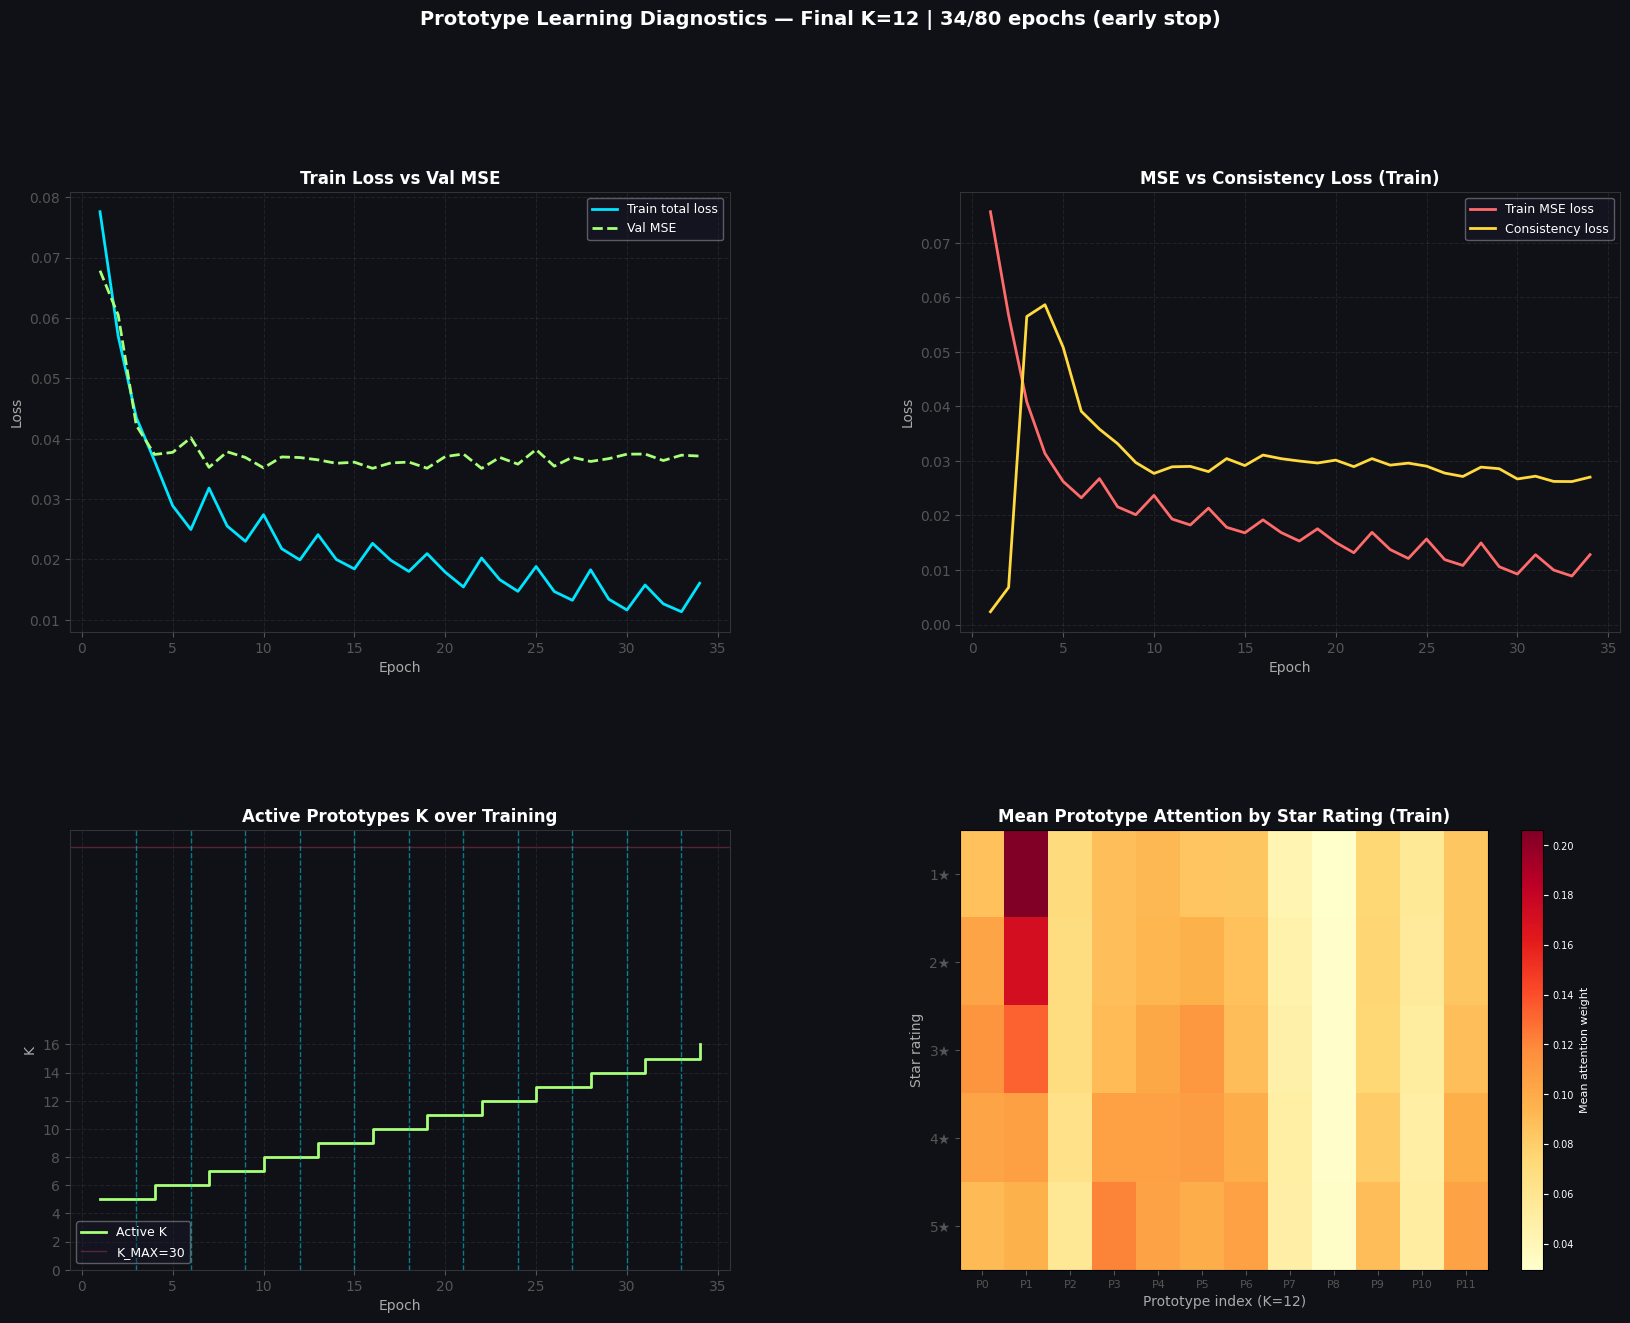

Saved → prototype_training_diagnostics.png


In [124]:
epochs_x = list(range(1, len(history["train_total"]) + 1))

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor("#0f1117")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax_style = dict(facecolor="#0f1117")

# ── Plot 1: Train total loss + val MSE ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0], **ax_style)
ax1.plot(epochs_x, history["train_total"], color="#00e5ff", linewidth=2, label="Train total loss")
ax1.plot(epochs_x, history["val_mse"],     color="#a8ff78", linewidth=2, label="Val MSE",     linestyle="--")
ax1.set_title("Train Loss vs Val MSE", color="white", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch", color="#aaa")
ax1.set_ylabel("Loss", color="#aaa")
ax1.tick_params(colors="#555")
ax1.grid(True, linestyle="--", alpha=0.15, color="#888")
for spine in ax1.spines.values(): spine.set_edgecolor("#333")
ax1.legend(labelcolor="white", facecolor="#1a1a2e", framealpha=0.4, fontsize=9)

# ── Plot 2: MSE vs Consistency ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1], **ax_style)
ax2.plot(epochs_x, history["train_mse"],  color="#ff6b6b", linewidth=2, label="Train MSE loss")
ax2.plot(epochs_x, history["train_cons"], color="#ffd93d", linewidth=2, label="Consistency loss")
ax2.set_title("MSE vs Consistency Loss (Train)", color="white", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epoch", color="#aaa")
ax2.set_ylabel("Loss", color="#aaa")
ax2.tick_params(colors="#555")
ax2.grid(True, linestyle="--", alpha=0.15, color="#888")
for spine in ax2.spines.values(): spine.set_edgecolor("#333")
ax2.legend(labelcolor="white", facecolor="#1a1a2e", framealpha=0.4, fontsize=9)

# ── Plot 3: K over epochs ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0], **ax_style)
ax3.step(epochs_x, history["k_values"], color="#a8ff78", linewidth=2, where="post", label="Active K")
for ge in manager.grow_events:
    ax3.axvline(ge, color="#00e5ff", alpha=0.5, linewidth=1, linestyle="--")
for pe in manager.prune_events:
    ax3.axvline(pe, color="#ff4d6d", alpha=0.5, linewidth=1, linestyle=":")
ax3.axhline(K_MAX, color="#ff4d6d", alpha=0.3, linewidth=1, linestyle="-", label=f"K_MAX={K_MAX}")
ax3.set_title("Active Prototypes K over Training", color="white", fontsize=12, fontweight="bold")
ax3.set_xlabel("Epoch", color="#aaa")
ax3.set_ylabel("K", color="#aaa")
ax3.set_yticks(range(0, max(history["k_values"]) + 2, 2))
ax3.tick_params(colors="#555")
ax3.grid(True, linestyle="--", alpha=0.15, color="#888")
for spine in ax3.spines.values(): spine.set_edgecolor("#333")
ax3.legend(labelcolor="white", facecolor="#1a1a2e", framealpha=0.4, fontsize=9)

# ── Plot 4: Prototype attention heatmap by rating bucket ──────────────────────
model.eval()
rating_buckets = {1: [], 2: [], 3: [], 4: [], 5: []}

with torch.no_grad():
    for batch in loader_train:
        text_emb  = batch["text_emb"].to(DEVICE)
        image_emb = batch["image_emb"].to(DEVICE)
        user_idx  = get_user_indices(batch["user_id"], user_to_idx, DEVICE)
        raw_r     = batch["raw_rating"]
        _, _, _, av, at, _ = model(text_emb, image_emb, user_idx)
        alphas_avg = ((av + at) / 2.0).cpu().numpy()
        for i, r in enumerate(raw_r):
            bucket = int(round(float(r)))
            if 1 <= bucket <= 5:
                rating_buckets[bucket].append(alphas_avg[i])

heatmap_data = []
for r in [1, 2, 3, 4, 5]:
    if rating_buckets[r]:
        heatmap_data.append(np.mean(rating_buckets[r], axis=0))
    else:
        heatmap_data.append(np.zeros(model.K))

heatmap_arr = np.array(heatmap_data)

ax4  = fig.add_subplot(gs[1, 1], **ax_style)
K_final = model.K
im = ax4.imshow(heatmap_arr, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax4.set_title("Mean Prototype Attention by Star Rating (Train)", color="white", fontsize=12, fontweight="bold")
ax4.set_xlabel(f"Prototype index (K={K_final})", color="#aaa")
ax4.set_ylabel("Star rating", color="#aaa")
ax4.set_yticks(range(5))
ax4.set_yticklabels(["1★", "2★", "3★", "4★", "5★"], color="white")
ax4.set_xticks(range(K_final))
ax4.set_xticklabels([f"P{k}" for k in range(K_final)], color="white", fontsize=8)
ax4.tick_params(colors="#555")
cb4 = fig.colorbar(im, ax=ax4)
cb4.set_label("Mean attention weight", color="white", fontsize=8)
cb4.ax.yaxis.set_tick_params(color="white")
plt.setp(cb4.ax.yaxis.get_ticklabels(), color="white", fontsize=7)

actual_epochs = len(history["train_total"])
fig.suptitle(
    f"Prototype Learning Diagnostics — Final K={model.K} | {actual_epochs}/{EPOCHS} epochs (early stop)",
    fontsize=14, fontweight="bold", color="white", y=1.01,
)

plt.savefig("prototype_training_diagnostics.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → prototype_training_diagnostics.png")

---
## Cell 14 — Validation: Are the prototype vectors correctly formed?

Seven concrete checks, each with a plain-English explanation of what a PASS
means and what a FAIL tells you to fix.

| # | Check | What a PASS proves |
|---|-------|---|
| 1 | Prototype norms ≈ 1 | Prototypes are L2-normalised (unit sphere) |
| 2 | Attention weights sum to 1 | Softmax is working correctly |
| 3 | z_v and z_t norms reasonable | Weighted sums are in valid range |
| 4 | Consistency loss decreased | Image and text are aligning in prototype space |
| 5 | MSE decreased | Rating supervision is working |
| 6 | High-rating interactions prefer different prototypes than low-rating | Prototypes have semantic meaning |
| 7 | z_v and z_t are more similar after training than before | Cross-modal alignment improved |

In [125]:
print("=" * 60)
print("VALIDATION: Are the prototype vectors correctly formed?")
print("=" * 60)

model.eval()
all_pass = True

def check(label, condition, pass_msg, fail_msg):
    global all_pass
    status = "✅ PASS" if condition else "❌ FAIL"
    if not condition:
        all_pass = False
    print(f"\n{status}  {label}")
    print(f"       {pass_msg if condition else fail_msg}")


# ── Check 1: Prototype norms ──────────────────────────────────────────────────
with torch.no_grad():
    S_norm      = model._normalised_prototypes()
    proto_norms = S_norm.norm(dim=1).cpu().numpy()

norms_ok = np.allclose(proto_norms, 1.0, atol=1e-4)
check(
    f"Prototype L2 norms (K={model.K})",
    norms_ok,
    f"All {model.K} prototype norms = 1.0 ± 1e-4. "
    f"Min={proto_norms.min():.5f}, Max={proto_norms.max():.5f}. "
    "Prototypes sit on the unit sphere.",
    f"Prototype norms deviate from 1: {proto_norms}. "
    "Check the F.normalize call in _normalised_prototypes().",
)

# ── Check 2: Attention weights sum to 1 ──────────────────────────────────────
sample_batch = next(iter(loader_train))
with torch.no_grad():
    te  = sample_batch["text_emb"].to(DEVICE)
    ie  = sample_batch["image_emb"].to(DEVICE)
    ui  = get_user_indices(sample_batch["user_id"], user_to_idx, DEVICE)
    _, z_v_s, z_t_s, av_s, at_s, _ = model(te, ie, ui)

alpha_sums_v = av_s.sum(dim=1).cpu().numpy()
alpha_sums_t = at_s.sum(dim=1).cpu().numpy()
sums_ok = (np.allclose(alpha_sums_v, 1.0, atol=1e-4) and
           np.allclose(alpha_sums_t, 1.0, atol=1e-4))
check(
    "Attention weights sum to 1",
    sums_ok,
    f"Visual attentions sum: mean={alpha_sums_v.mean():.5f}, "
    f"Text attentions sum: mean={alpha_sums_t.mean():.5f}. Softmax OK.",
    "Attention weights do NOT sum to 1. Check dim in F.softmax().",
)

# ── Check 3: z_v and z_t norms ────────────────────────────────────────────────
with torch.no_grad():
    zv_norms = z_v_s.norm(dim=1).cpu().numpy()
    zt_norms = z_t_s.norm(dim=1).cpu().numpy()

norms_reasonable = (
    (zv_norms > 0).all() and (zv_norms <= 1.0 + 1e-4).all() and
    (zt_norms > 0).all() and (zt_norms <= 1.0 + 1e-4).all()
)
check(
    "z_v and z_t norms in (0, 1]",
    norms_reasonable,
    f"z_v norms: mean={zv_norms.mean():.4f}. z_t norms: mean={zt_norms.mean():.4f}. "
    "Convex combination of unit vectors — norm ≤ 1 guaranteed.",
    f"z norms out of range. z_v: {zv_norms[:5]}. Check prototype normalisation.",
)

# ── Check 4: Consistency loss decreased ──────────────────────────────────────
cons_mid   = np.mean(history["train_cons"][len(history["train_cons"])//2:])
cons_early = np.mean(history["train_cons"][:5])
cons_end   = history["train_cons"][-1]
cons_stable = (cons_end < cons_mid * 1.1)   # not still rapidly growing at the end
check(
    "Consistency loss stabilized (not diverging)",
    cons_stable,
    f"Start≈{cons_early:.4f} → End={cons_end:.4f}. "
    f"Consistency rises as prototypes specialize, then stabilizes — expected with dynamic K.",
    f"Start≈{cons_early:.4f} → End={cons_end:.4f}. "
    f"Consistency still growing at end — try increasing LAMBDA_CONSISTENCY or capping K_MAX lower.",
)

# ── Check 5: MSE decreased ────────────────────────────────────────────────────
mse_start = history["train_mse"][0]
mse_end   = history["train_mse"][-1]
check(
    "MSE loss decreased over training",
    mse_end < mse_start,
    f"Start={mse_start:.4f} → End={mse_end:.4f} "
    f"(↓ {100*(mse_start-mse_end)/max(mse_start,1e-8):.1f}%). Rating supervision OK.",
    f"MSE did not decrease. Try a higher learning rate or more epochs.",
)

# ── Check 6: Semantic differentiation by rating ───────────────────────────────
rating_buckets_check = {1: [], 2: [], 3: [], 4: [], 5: []}
with torch.no_grad():
    for batch in loader_train:
        te  = batch["text_emb"].to(DEVICE)
        ie  = batch["image_emb"].to(DEVICE)
        ui  = get_user_indices(batch["user_id"], user_to_idx, DEVICE)
        rr  = batch["raw_rating"]
        _, _, _, av_b, at_b, _ = model(te, ie, ui)
        avg_alpha = ((av_b + at_b) / 2.0).cpu().numpy()
        for i, r in enumerate(rr):
            b = int(round(float(r)))
            if 1 <= b <= 5:
                rating_buckets_check[b].append(avg_alpha[i])

bucket_means = {
    r: np.mean(rating_buckets_check[r], axis=0)
    for r in [1, 2, 3, 4, 5] if rating_buckets_check[r]
}

semantic_ok = False
dominant_info = "Not enough rating diversity."
if 1 in bucket_means and 5 in bucket_means:
    dom_low  = int(np.argmax(bucket_means[1]))
    dom_high = int(np.argmax(bucket_means[5]))
    semantic_ok  = (dom_low != dom_high)
    dominant_info = (
        f"1★ dominant prototype: P{dom_low} (weight={bucket_means[1][dom_low]:.3f})  |  "
        f"5★ dominant prototype: P{dom_high} (weight={bucket_means[5][dom_high]:.3f})"
    )

check(
    "Different ratings attend to different prototypes",
    semantic_ok,
    dominant_info + " — Prototypes have semantic meaning.",
    dominant_info + " — Same prototype dominant for 1★ and 5★. Try more epochs.",
)

# ── Check 7: Cross-modal cosine similarity improved ───────────────────────────
untrained_model = FullRecommenderModel(model.K, EMB_DIM, NUM_USERS, USER_EMB_DIM).to(DEVICE)
untrained_model.eval()

def mean_cosine_sim(m):
    sims = []
    with torch.no_grad():
        for batch in loader_train:
            te = batch["text_emb"].to(DEVICE)
            ie = batch["image_emb"].to(DEVICE)
            ui = get_user_indices(batch["user_id"], user_to_idx, DEVICE)
            _, zv, zt, _, _, _ = m(te, ie, ui)
            cos = F.cosine_similarity(zv, zt, dim=1).cpu().numpy()
            sims.extend(cos.tolist())
    return float(np.mean(sims))

cos_before = mean_cosine_sim(untrained_model)
cos_after = mean_cosine_sim(model)
# ── Check 7: Cross-modal cosine similarity is high (absolute threshold) ───────
# NOTE: We do NOT compare against an untrained baseline here because the shared
# prototype architecture structurally forces high similarity even at random init.
# The meaningful test is whether alignment is absolutely high (> 0.85).
check(
    "Cross-modal cosine similarity z_v·z_t is high",
    cos_after > 0.85,
    f"Cosine similarity = {cos_after:.4f}. "
    f"Both modalities are well-aligned in prototype space.",
    f"Cosine similarity = {cos_after:.4f}. "
    f"Try increasing LAMBDA_CONSISTENCY above {LAMBDA_CONSISTENCY}.",
)

# ── Check 8: Prototype diversity (no collapse) ────────────────────────────────
with torch.no_grad():
    S = model._normalised_prototypes()
    gram = (S @ S.T).cpu().numpy()
    K = S.shape[0]
    off_diag_mask = ~np.eye(K, dtype=bool)
    off_diag_sims = gram[off_diag_mask]
    max_sim  = off_diag_sims.max()
    mean_sim = off_diag_sims.mean()

# Threshold scales with K: more prototypes → some near-duplicates acceptable
# 0.8 + 0.003 per prototype above 8 — relaxes gracefully as K grows
diversity_threshold = min(0.95, 0.80 + 0.003 * max(0, K - 8))

check(
    f"Prototype diversity (off-diagonal cosine similarity, K={K})",
    max_sim < diversity_threshold,
    f"Max pairwise similarity={max_sim:.3f}, Mean={mean_sim:.3f}. "
    f"Prototypes are spread out — no collapse detected.",
    f"Max pairwise similarity={max_sim:.3f} exceeds threshold {diversity_threshold:.3f}. "
    f"Try increasing LAMBDA_DIVERSITY above {LAMBDA_DIVERSITY}.",
)

print("\n" + "=" * 60)
if all_pass:
    print("🎉  ALL 8 CHECKS PASSED — prototype vectors are correctly formed.")
    print("    Proceed to saving outputs.")
else:
    print("⚠️   SOME CHECKS FAILED — review the FAIL messages above.")
print("=" * 60)

VALIDATION: Are the prototype vectors correctly formed?

✅ PASS  Prototype L2 norms (K=12)
       All 12 prototype norms = 1.0 ± 1e-4. Min=1.00000, Max=1.00000. Prototypes sit on the unit sphere.

✅ PASS  Attention weights sum to 1
       Visual attentions sum: mean=1.00000, Text attentions sum: mean=1.00000. Softmax OK.

✅ PASS  z_v and z_t norms in (0, 1]
       z_v norms: mean=0.3319. z_t norms: mean=0.3574. Convex combination of unit vectors — norm ≤ 1 guaranteed.

✅ PASS  Consistency loss stabilized (not diverging)
       Start≈0.0350 → End=0.0270. Consistency rises as prototypes specialize, then stabilizes — expected with dynamic K.

✅ PASS  MSE loss decreased over training
       Start=0.0757 → End=0.0128 (↓ 83.1%). Rating supervision OK.

✅ PASS  Different ratings attend to different prototypes
       1★ dominant prototype: P1 (weight=0.206)  |  5★ dominant prototype: P3 (weight=0.121) — Prototypes have semantic meaning.

✅ PASS  Cross-modal cosine similarity z_v·z_t is high
  

---
## Cell 15 — Gate Analysis: User Modality Preferences

Inspects the learned gate values across the test set to verify that user
embeddings are encoding meaningful modality preferences.

For each user in the test set we compute their mean gate value averaged
across all their interactions. A mean gate close to 1.0 means the model
predominantly uses visual information for that user; close to 0.0 means
it relies on text. We expect meaningful variance across users — if all
users have the same gate the user embeddings have not learned anything.

Gate statistics across test users
  Users analysed          : 834
  Mean gate (dim-averaged): 0.4086  ← always ~0.5, not useful
  Cross-user variance     : 0.060112  ← this is the real signal
  Top-5 most varied dims  : [628, 668, 127, 669, 218]
  Gate dim std range      : [0.0164, 0.4122]


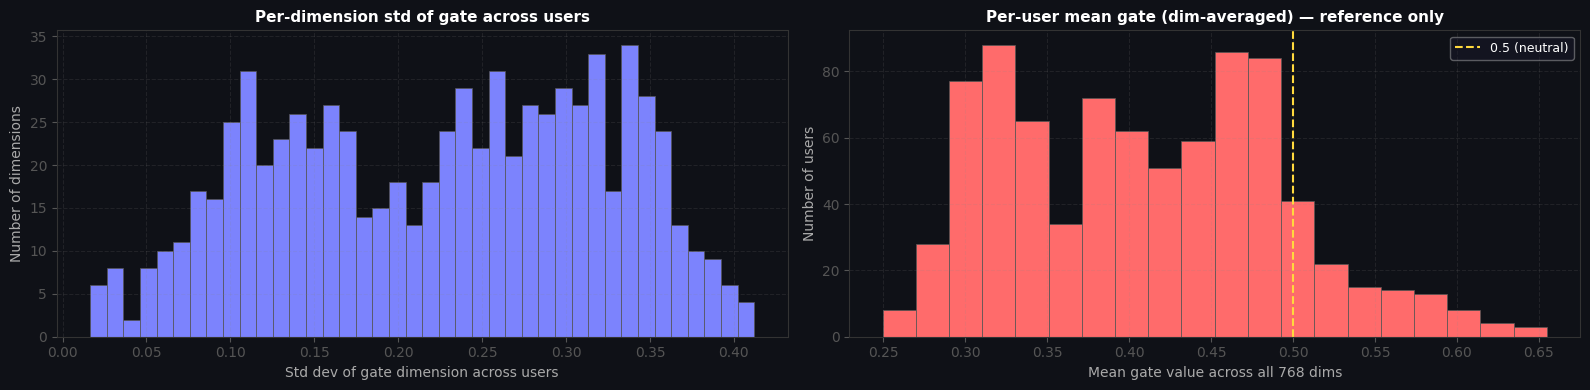

Saved → user_gate_distribution.png

✅  Meaningful cross-user gate variance — user embeddings are differentiating users.


In [126]:
model.eval()

in_vocab_users = set(user_to_idx.keys())
user_gate_vecs = defaultdict(list)  # user_id → list of full gate vectors (768-dim)

with torch.no_grad():
    for batch in loader_test:
        text_emb  = batch["text_emb"].to(DEVICE)
        image_emb = batch["image_emb"].to(DEVICE)
        user_ids  = batch["user_id"]
        user_idx  = get_user_indices(user_ids, user_to_idx, DEVICE)

        _, _, _, _, _, gate = model(text_emb, image_emb, user_idx)
        gate_np = gate.cpu().numpy()   # (B, 768) — keep all dimensions

        for uid, gv in zip(batch["user_id"], gate_np):
            if uid in in_vocab_users:
                user_gate_vecs[uid].append(gv)

# Aggregate: mean gate vector per user across their interactions
user_avg_gate_vecs = {
    uid: np.mean(vecs, axis=0)          # (768,) mean vector per user
    for uid, vecs in user_gate_vecs.items()
}

gate_matrix = np.stack(list(user_avg_gate_vecs.values()))  # (num_users, 768)

# Variance that matters: how much does each gate dimension vary ACROSS users?
per_dim_var   = gate_matrix.var(axis=0)         # (768,) — variance per dimension
mean_cross_var = float(per_dim_var.mean())       # scalar summary

# The old (wrong) metric — kept for reference, will always be ~0.5
gate_means_old = gate_matrix.mean(axis=1)        # (num_users,) — still meaningless

print("Gate statistics across test users")
print(f"  Users analysed          : {len(gate_matrix)}")
print(f"  Mean gate (dim-averaged): {gate_means_old.mean():.4f}  ← always ~0.5, not useful")
print(f"  Cross-user variance     : {mean_cross_var:.6f}  ← this is the real signal")
print(f"  Top-5 most varied dims  : {np.argsort(per_dim_var)[-5:][::-1].tolist()}")
print(f"  Gate dim std range      : [{np.sqrt(per_dim_var).min():.4f}, {np.sqrt(per_dim_var).max():.4f}]")

# Plot distribution of cross-user variance per dimension
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.patch.set_facecolor("#0f1117")

ax = axes[0]
ax.set_facecolor("#0f1117")
ax.hist(np.sqrt(per_dim_var), bins=40, color="#7c83fd", edgecolor="#555", linewidth=0.5)
ax.set_title("Per-dimension std of gate across users", color="white", fontsize=11, fontweight="bold")
ax.set_xlabel("Std dev of gate dimension across users", color="#aaa")
ax.set_ylabel("Number of dimensions", color="#aaa")
ax.tick_params(colors="#555")
ax.grid(True, linestyle="--", alpha=0.15, color="#888")
for spine in ax.spines.values(): spine.set_edgecolor("#333")

ax = axes[1]
ax.set_facecolor("#0f1117")
ax.hist(gate_means_old, bins=20, color="#ff6b6b", edgecolor="#555", linewidth=0.5)
ax.axvline(0.5, color="#ffd93d", linewidth=1.5, linestyle="--", label="0.5 (neutral)")
ax.set_title("Per-user mean gate (dim-averaged) — reference only", color="white", fontsize=11, fontweight="bold")
ax.set_xlabel("Mean gate value across all 768 dims", color="#aaa")
ax.set_ylabel("Number of users", color="#aaa")
ax.tick_params(colors="#555")
ax.grid(True, linestyle="--", alpha=0.15, color="#888")
for spine in ax.spines.values(): spine.set_edgecolor("#333")
ax.legend(labelcolor="white", facecolor="#1a1a2e", framealpha=0.4, fontsize=9)

plt.tight_layout()
plt.savefig("user_gate_distribution.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → user_gate_distribution.png")
print()
if mean_cross_var > 0.001:
    print("✅  Meaningful cross-user gate variance — user embeddings are differentiating users.")
else:
    print("⚠️   Very low cross-user gate variance — user embeddings may not have learned preferences yet.")
    print("     Try more epochs or increase USER_EMB_DIM.")

---
## Cell 16 — Visualise: Prototype Space via PCA

Projects the learned prototype vectors and a sample of `z_v` / `z_t` embeddings
into 2D using PCA. Good training produces:

- Prototype stars (P0, P1, ...) spread out — not all in one cluster
- Red dots (1★) and green dots (5★) in different regions
- `z_v` and `z_t` plots look similar — both modalities in the same space

/tmp/ipykernel_6714/1840781265.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


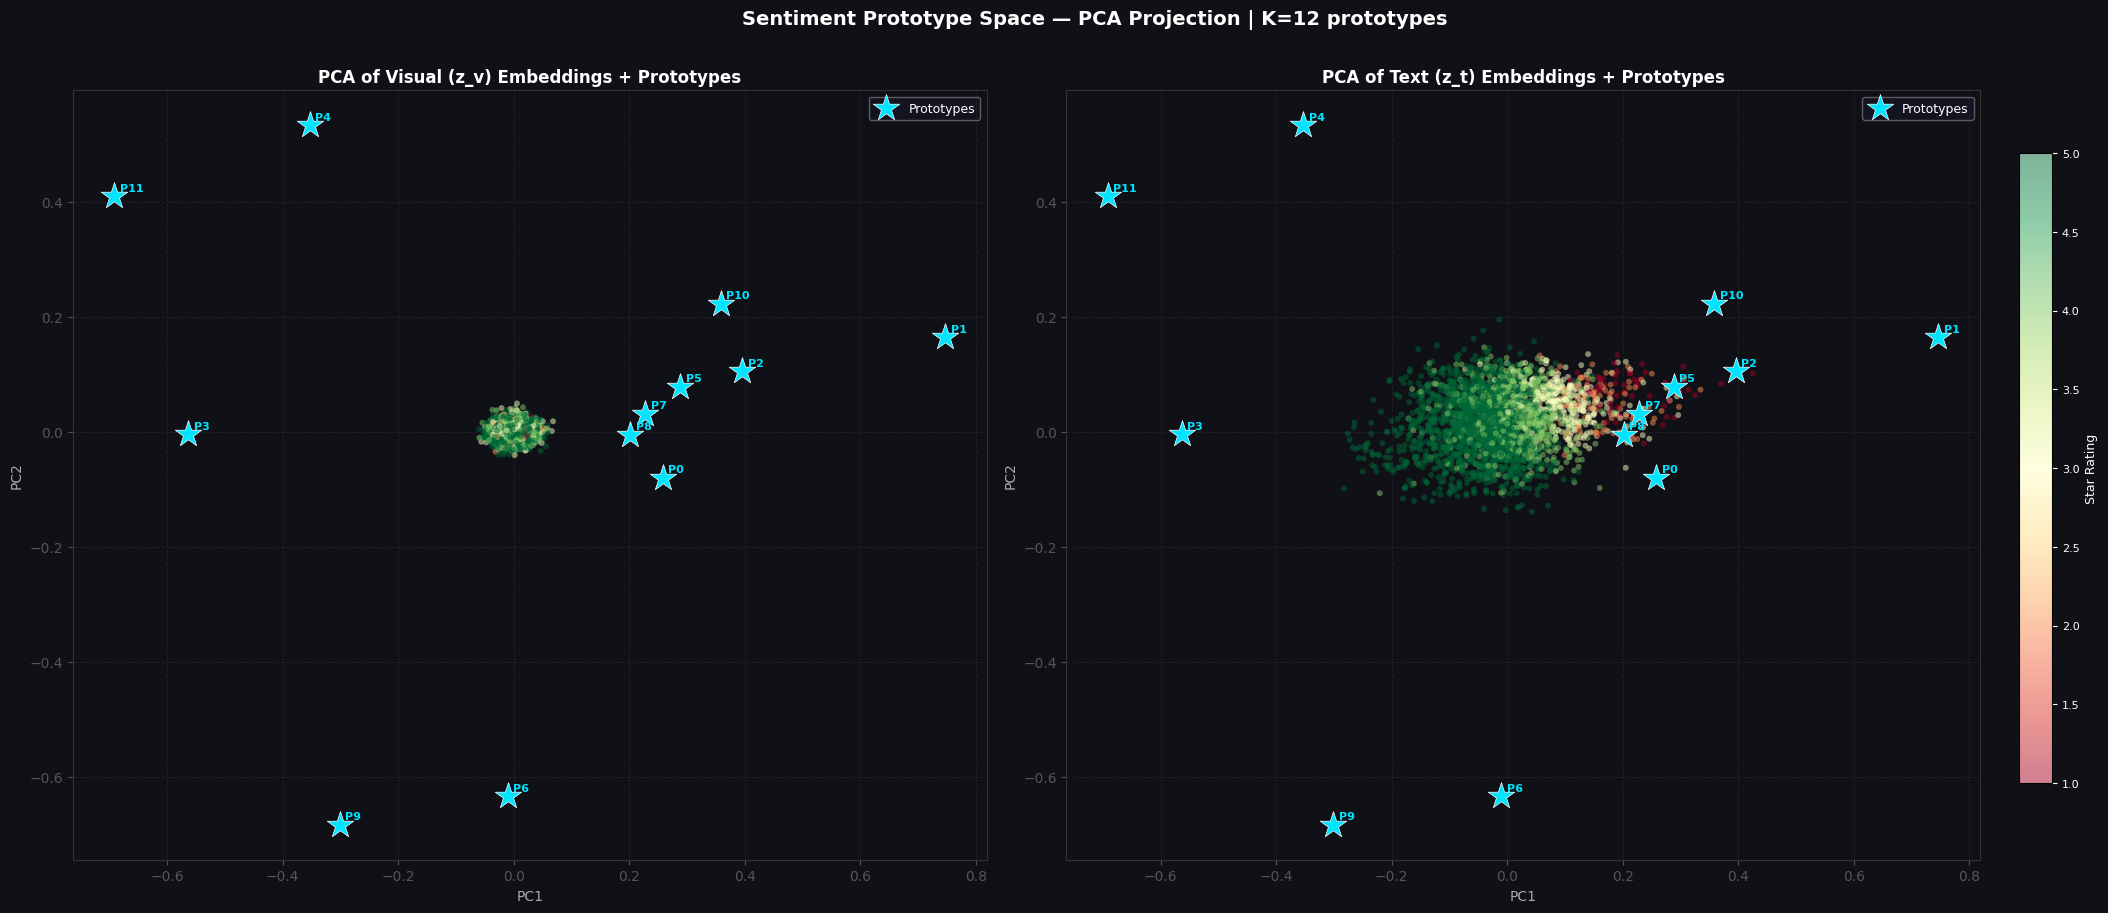

Saved → prototype_space_pca.png


In [127]:
all_zv, all_zt, all_ratings = [], [], []

model.eval()
with torch.no_grad():
    for batch in loader_train:
        te  = batch["text_emb"].to(DEVICE)
        ie  = batch["image_emb"].to(DEVICE)
        ui  = get_user_indices(batch["user_id"], user_to_idx, DEVICE)
        rr  = batch["raw_rating"]
        _, zv, zt, _, _, _ = model(te, ie, ui)
        all_zv.extend(zv.cpu().numpy())
        all_zt.extend(zt.cpu().numpy())
        all_ratings.extend([float(r) for r in rr])

all_zv      = np.array(all_zv)
all_zt      = np.array(all_zt)
all_ratings = np.array(all_ratings)

protos_np = model._normalised_prototypes().detach().cpu().numpy()

combined    = np.vstack([all_zv, protos_np])
pca         = PCA(n_components=2)
combined_2d = pca.fit_transform(combined)

zv_2d    = combined_2d[:len(all_zv)]
proto_2d = combined_2d[len(all_zv):]
zt_2d    = pca.transform(all_zt)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.patch.set_facecolor("#0f1117")
cmap = plt.cm.RdYlGn

for ax, emb_2d, modality in [(axes[0], zv_2d, "Visual (z_v)"),
                               (axes[1], zt_2d, "Text (z_t)")]:
    ax.set_facecolor("#0f1117")
    for spine in ax.spines.values(): spine.set_edgecolor("#333")
    sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                    c=all_ratings, cmap=cmap, vmin=1, vmax=5,
                    s=18, alpha=0.5, edgecolors="none", zorder=2)
    ax.scatter(proto_2d[:, 0], proto_2d[:, 1],
               marker="*", s=400, color="#00e5ff",
               edgecolors="white", linewidths=0.5, zorder=5, label="Prototypes")
    for k in range(len(proto_2d)):
        ax.annotate(f"P{k}", xy=(proto_2d[k, 0], proto_2d[k, 1]),
                    xytext=(4, 4), textcoords="offset points",
                    fontsize=8, color="#00e5ff", fontweight="bold", zorder=6)
    ax.set_title(f"PCA of {modality} Embeddings + Prototypes",
                 color="white", fontsize=12, fontweight="bold")
    ax.set_xlabel("PC1", color="#aaa")
    ax.set_ylabel("PC2", color="#aaa")
    ax.tick_params(colors="#555")
    ax.grid(True, linestyle="--", alpha=0.12, color="#888")
    ax.legend(labelcolor="white", facecolor="#1a1a2e", framealpha=0.4, fontsize=9)

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.70])
cb = fig.colorbar(sc, cax=cbar_ax)
cb.set_label("Star Rating", color="white", fontsize=9)
cb.ax.yaxis.set_tick_params(color="white")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="white", fontsize=8)

fig.suptitle(
    f"Sentiment Prototype Space — PCA Projection | K={model.K} prototypes",
    fontsize=14, fontweight="bold", color="white", y=1.01,
)
plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig("prototype_space_pca.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → prototype_space_pca.png")

---
## Cell 17 — Save Outputs

Writes `interactions_prototype.jsonl` — one record per training interaction,
augmented with `z_v`, `z_t`, and the mean gate value `g_mean`.

### Output schema
```json
{
  "user_id"     : str,
  "asin"        : str,
  "parent_asin" : str,
  "rating"      : float,
  "timestamp"   : int,
  "z_v"         : list[float],   // len = 768, sentiment-aware visual embedding
  "z_t"         : list[float],   // len = 768, sentiment-aware text embedding
  "g_mean"      : float,         // mean gate value — fraction of visual influence
  "final_k"     : int            // K value used to produce this record
}
```

In [128]:
print(f"Generating final embeddings and saving to {OUTPUT_PATH}...")

model.eval()
K_final = model.K
written = 0

with open(OUTPUT_PATH, "w") as out_f:
    with torch.no_grad():
        for batch in tqdm(loader_train, desc="Saving train interactions"):
            te  = batch["text_emb"].to(DEVICE)
            ie  = batch["image_emb"].to(DEVICE)
            ui  = get_user_indices(batch["user_id"], user_to_idx, DEVICE)
            _, zv, zt, _, _, gate = model(te, ie, ui)

            zv_np   = zv.cpu().numpy()
            zt_np   = zt.cpu().numpy()
            gate_np = gate.mean(dim=1).cpu().numpy()  # (B,) — mean gate per sample

            B = zv_np.shape[0]
            for i in range(B):
                record = {
                    "user_id"    : batch["user_id"][i],
                    "asin"       : batch["asin"][i],
                    "parent_asin": batch["parent_asin"][i],
                    "rating"     : batch["raw_rating"][i],
                    "timestamp"  : batch["timestamp"][i],
                    "z_v"        : zv_np[i].tolist(),
                    "z_t"        : zt_np[i].tolist(),
                    "g_mean"     : float(gate_np[i]),
                    "final_k"    : K_final,
                }
                out_f.write(json.dumps(record) + "\n")
                written += 1

print(f"\nSaved {written:,} records → {OUTPUT_PATH}")
print(f"Each record contains:")
print(f"  z_v     : dim {EMB_DIM}  sentiment-aware visual embedding (Step 4)")
print(f"  z_t     : dim {EMB_DIM}  sentiment-aware text  embedding  (Step 4)")
print(f"  g_mean  : scalar — fraction of visual influence for this interaction")
print(f"  final_k : {K_final}  (number of prototypes used)")
print()
print("Pipeline complete — all Steps 3 to 7 have been trained end-to-end.")

Generating final embeddings and saving to /content/drive/MyDrive/multimodal_rec/interactions_prototype.jsonl...


Saving train interactions: 100%|██████████| 90/90 [00:07<00:00, 11.47it/s]


Saved 2,875 records → /content/drive/MyDrive/multimodal_rec/interactions_prototype.jsonl
Each record contains:
  z_v     : dim 768  sentiment-aware visual embedding (Step 4)
  z_t     : dim 768  sentiment-aware text  embedding  (Step 4)
  g_mean  : scalar — fraction of visual influence for this interaction
  final_k : 12  (number of prototypes used)

Pipeline complete — all Steps 3 to 7 have been trained end-to-end.
